# Movies, Ratings & Oscars — Exploratory Analysis

**Research questions**
1. Does a bigger budget produce more revenue?
2. Do Oscar-winning movies receive higher ratings?
3. Which genres generate the highest revenue?
4. Does movie runtime influence ratings?
5. Which directors consistently produce successful movies?

**Data sources**
- `title_basics.tsv` (**movies_2**) — IMDb titles: `tconst`, `primaryTitle`, `startYear`, `runtimeMinutes`, `genres`.
- `title.ratings.tsv` (**ratings**) — IMDb ratings: `tconst`, `averageRating`, `numVotes`.
- `TMDB_movie_dataset_v11.csv` (**movies**) — budget, revenue, `imdb_id`. Used to fill values *not* present in the movies_2 + ratings join (mainly **budget** / **revenue**).
- `full_data.csv` — Oscar nominations/wins, tab-separated, `FilmId` links to IMDb ids (`tt...`).

**Build strategy.** The analysis table is rebuilt from `movies_2` ⋈ `ratings` on `tconst`. Columns used in
the analysis but absent from that join (budget, revenue) — plus per-row gaps in the shared columns — are
filled from a slim TMDB dataset keeping only `imdb_id` + the needed fields, joined `imdb_id` ↔ `tconst`.

Join key throughout: `tconst`  ↔  TMDB `imdb_id`  ↔  Oscar `FilmId`.

## 1. Setup

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("output", exist_ok=True)   # all CSVs saved here

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## 2. Load data

In [12]:
# --- movies_2: IMDb title basics ---
basics = pd.read_csv(
    "title_basics.tsv", sep="\t", na_values="\\N", low_memory=False,
    usecols=["tconst", "titleType", "primaryTitle",
             "startYear", "runtimeMinutes", "genres"],
    dtype={"startYear": "str", "runtimeMinutes": "str"})
basics = basics[basics["titleType"] == "movie"].copy()   # keep films only
print("movies_2 (movie rows):", basics.shape)
basics.head(3)


movies_2 (movie rows): (750860, 6)


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres
8,tt0000009,movie,Miss Jerry,1894,45,Romance
144,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897,100,"Documentary,News,Sport"
498,tt0000502,movie,Bohemios,1905,100,NaN


In [47]:
basics.dtypes

tconst            object
titleType         object
primaryTitle      object
startYear         object
runtimeMinutes    object
genres            object
dtype: object

In [ ]:
import csv
import unicodedata

# Make a copy
basics_new = basics.copy()

# Function to remove accents and quotes
def clean_text(v):
    if not isinstance(v, str):
        return v

    # Remove accents (é -> e, ü -> u, etc.)
    v = unicodedata.normalize("NFKD", v).encode("ascii", "ignore").decode("ascii")

    # Remove double quotes
    v = v.replace('"', '')

    # Remove carriage returns/newlines inside fields
    v = v.replace("\r", " ").replace("\n", " ")

    return v.strip()

# Apply to every cell
basics_new = basics_new.map(clean_text)


# Export
basics_new.to_csv(
    "output/movies_base.csv",
    sep=",",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_MINIMAL
)

print("movies_base.csv:", basics_new.shape)

In [14]:
# --- ratings: IMDb averageRating / numVotes ---
ratings = pd.read_csv("title.ratings.tsv", sep="\t", na_values="\\N")
print("ratings:", ratings.shape)
ratings.head(3)

ratings: (1690132, 3)


,tconst,averageRating,numVotes
0,tt0000001,5.70,2214
1,tt0000002,5.40,320
2,tt0000003,6.40,2351


In [45]:
ratings.averageRating.unique()

array([ 5.7,  5.4,  6.4,  5.1,  6.2,  5. ,  5.3,  6.8,  5.2,  7.4,  7.1,
        6.1,  5.9,  4.5,  4.7,  3.8,  4. ,  5.6,  5.5,  4.9,  4.4,  4.2,
        4.1,  6.7,  3.4,  3.5,  3.6,  4.8,  3.7,  3.1,  3.3,  6.3,  3.9,
        4.3,  4.6,  6. ,  5.8,  3.2,  6.5,  2.9,  2.6,  3. ,  2.8,  2.5,
        2.3,  2.1,  8.1,  7.2,  2.7,  7.3,  6.9,  6.6,  2.2,  1.9,  1.8,
        2. ,  1.7,  2.4,  7.9,  7.8,  7. ,  8.6,  7.6,  7.7,  8. ,  8.9,
        8.3,  9. ,  8.5,  9.1,  7.5,  8.4,  8.8,  8.2,  1.3,  8.7,  1. ,
        1.6,  1.1,  9.3,  9.4,  1.4,  1.5,  1.2,  9.2,  9.6,  9.5,  9.8,
        9.7,  9.9, 10. ])

In [44]:
ratings.averageRating.unique()
ratings["averageRating"].dtype

dtype('float64')

In [ ]:
import csv
import unicodedata

# Make a copy
ratings_new = ratings.copy()

# Function to remove accents and quotes
def clean_text(v):
    if not isinstance(v, str):
        return v

    # Remove accents (é -> e, ü -> u, etc.)
    v = unicodedata.normalize("NFKD", v).encode("ascii", "ignore").decode("ascii")

    # Remove double quotes
    v = v.replace('"', '')

    # Remove carriage returns/newlines inside fields
    v = v.replace("\r", " ").replace("\n", " ")

    return v.strip()

# Apply to every cell
ratings_new = ratings_new.map(clean_text)


# Export
ratings_new.to_csv(
    "output/ratings.csv",
    sep=",",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_MINIMAL,
    float_format="%.1f"
)

print("ratings.csv:", ratings_new.shape)

In [16]:
# --- movies: TMDB (fallback source for budget/revenue + per-row gaps) ---
movies = pd.read_csv("TMDB_movie_dataset_v11.csv")
print("movies (TMDB):", movies.shape)
movies[["imdb_id", "title", "budget", "revenue",
        "vote_average", "vote_count", "runtime", "genres"]].head(3)

movies (TMDB): (1451806, 24)


,imdb_id,title,budget,revenue,vote_average,vote_count,runtime,genres
0,tt1375666,Inception,160000000,825532764,8.36,34495,148,"Action, Science Fiction, Adventure"
1,tt0816692,Interstellar,165000000,701729206,8.42,32571,169,"Adventure, Drama, Science Fiction"
2,tt0468569,The Dark Knight,185000000,1004558444,8.51,30619,152,"Drama, Action, Crime, Thriller"


In [ ]:
import csv
import unicodedata

# Make a copy
tmdb = movies.copy()

# Function to remove accents and quotes
def clean_text(v):
    if not isinstance(v, str):
        return v

    # Remove accents (é -> e, ü -> u, etc.)
    v = unicodedata.normalize("NFKD", v).encode("ascii", "ignore").decode("ascii")

    # Remove double quotes
    v = v.replace('"', '')

    # Remove carriage returns/newlines inside fields
    v = v.replace("\r", " ").replace("\n", " ")

    return v.strip()

# Apply to every cell
tmdb = tmdb.map(clean_text)


# Export
tmdb.to_csv(
    "output/tmdb.csv",
    sep=",",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_MINIMAL
)

print("tmdb.csv:", tmdb.shape)

In [18]:
oscars = pd.read_csv("full_data.csv", sep="\t")
print(oscars.shape)
oscars.head(3)



(12137, 14)


,Ceremony,Year,Class,CanonicalCategory,Category,Film,FilmId,Name,Nominees,NomineeIds,Winner,Detail,Note,Citation
0,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,The Noose|The Patent Leather Kid,tt0019217|tt0018253,Richard Barthelmess,Richard Barthelmess,nm0001932,NaN,Nickie Elkins|The Patent Leather Kid,NaN,NaN
1,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,The Last Command|The Way of All Flesh,tt0019071|tt0019553,Emil Jannings,Emil Jannings,nm0417837,True,General Dolgorucki [Grand Duke Sergius Alexand...,NaN,NaN
2,1,1927/28,Acting,ACTRESS IN A LEADING ROLE,ACTRESS,A Ship Comes In,tt0018389,Louise Dresser,Louise Dresser,nm0237571,NaN,Mrs. Pleznik,NaN,NaN


In [ ]:
import csv
import unicodedata

# Make a copy
oscars_2 = oscars.copy()

# Function to remove accents and quotes
def clean_text(v):
    if not isinstance(v, str):
        return v

    # Remove accents (é -> e, ü -> u, etc.)
    v = unicodedata.normalize("NFKD", v).encode("ascii", "ignore").decode("ascii")

    # Remove double quotes
    v = v.replace('"', '')

    # Remove carriage returns/newlines inside fields
    v = v.replace("\r", " ").replace("\n", " ")

    return v.strip()

# Apply to every cell
oscars_2 = oscars_2.map(clean_text)

# Drop Film column
oscars_2 = oscars_2.drop(columns=["Film"])

# Export
oscars_2.to_csv(
    "output/oscars_2.csv",
    sep=",",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_MINIMAL
)

print("oscars_db.csv:", oscars_2.shape)

## 3. Build the analysis table via joins

Done in visible steps (one cell each) so each join is easy to follow:

- **Step 1 — base:** `movies_2` ⋈ `ratings` on `tconst` (left join — every film, ratings where present).
- **Step 2 — `tmdb_needed`:** slim TMDB table with only the fields the analysis needs. `budget` / `revenue`
  exist *only* here; the other columns are fallbacks. De-duplicated to one row per `imdb_id`.
- **Step 3 — merged:** join `tmdb_needed` onto base via `imdb_id` ↔ `tconst` (left join).
- **Step 4 — `m`:** IMDb value first, **fall back to TMDB** where IMDb is missing (`combine_first`).
- **Step 5 — Oscars:** fold in `oscar_nominated`, `oscar_won` and `director` (via `FilmId` ↔ `imdb_id`).

The result is **one large final dataset `m`** — every question below just queries it.
`budget` / `revenue` of 0 in TMDB is treated as missing ("not reported", not "zero dollars").

In [20]:
# STEP 1 — BASE: movies_2 JOIN ratings on tconst (left: keep every film)
base = basics.merge(ratings, on="tconst", how="left")
print("base (movies_2 + ratings):", base.shape)
base.head(3)

base (movies_2 + ratings): (750860, 8)


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,1894,45,Romance,5.30,232.00
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897,100,"Documentary,News,Sport",5.30,602.00
2,tt0000502,movie,Bohemios,1905,100,NaN,3.60,27.00


In [21]:
# STEP 2 — tmdb_needed: slim TMDB table, only fields the analysis needs.
# budget/revenue live ONLY here; the rest are fallbacks for gaps in base.
tmdb_cols = ["imdb_id", "budget", "revenue",
             "title", "vote_average", "vote_count", "runtime",
             "release_date", "genres"]
tmdb_needed = movies[tmdb_cols].dropna(subset=["imdb_id"]).copy()

# 0 == not reported -> NaN for money & runtime
for c in ["budget", "revenue", "runtime"]:
    tmdb_needed[c] = tmdb_needed[c].replace(0, np.nan)
tmdb_needed["tmdb_year"] = pd.to_datetime(
    tmdb_needed["release_date"], errors="coerce").dt.year
tmdb_needed = tmdb_needed.drop(columns="release_date")

# one TMDB row per imdb_id (keep most-voted so the join can't fan out)
tmdb_needed = (tmdb_needed.sort_values("vote_count", ascending=False)
                          .drop_duplicates("imdb_id"))
# name TMDB fallbacks distinctly so the merge doesn't collide with base
tmdb_needed = tmdb_needed.rename(columns={
    "title": "title_tmdb", "vote_average": "va_tmdb", "vote_count": "vc_tmdb",
    "runtime": "runtime_tmdb", "genres": "genres_tmdb"})
print("tmdb_needed:", tmdb_needed.shape)
tmdb_needed.head(3)

tmdb_needed: (670730, 9)


,imdb_id,budget,revenue,title_tmdb,va_tmdb,vc_tmdb,runtime_tmdb,genres_tmdb,tmdb_year
0,tt1375666,"160,000,000.00","825,532,764.00",Inception,8.36,34495,148.00,"Action, Science Fiction, Adventure","2,010.00"
1,tt0816692,"165,000,000.00","701,729,206.00",Interstellar,8.42,32571,169.00,"Adventure, Drama, Science Fiction","2,014.00"
2,tt0468569,"185,000,000.00","1,004,558,444.00",The Dark Knight,8.51,30619,152.00,"Drama, Action, Crime, Thriller","2,008.00"


In [22]:
# STEP 3 — JOIN base + tmdb_needed on tconst == imdb_id (left: keep base rows)
merged = base.merge(tmdb_needed, left_on="tconst", right_on="imdb_id", how="left")
print("merged:", merged.shape)
merged.head(3)

merged: (750860, 17)


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,imdb_id,budget,revenue,title_tmdb,va_tmdb,vc_tmdb,runtime_tmdb,genres_tmdb,tmdb_year
0,tt0000009,movie,Miss Jerry,1894,45,Romance,5.30,232.00,tt0000009,NaN,NaN,Miss Jerry,5.00,3.00,45.00,Romance,"1,894.00"
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897,100,"Documentary,News,Sport",5.30,602.00,tt0000147,NaN,NaN,The Corbett-Fitzsimmons Fight,5.50,20.00,19.00,Documentary,"1,897.00"
2,tt0000502,movie,Bohemios,1905,100,NaN,3.60,27.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# STEP 4 — FINAL table `m`: take IMDb value first, fall back to TMDB where missing
m = pd.DataFrame({
    "imdb_id":      merged["tconst"],
    "title":        merged["primaryTitle"].combine_first(merged["title_tmdb"]),
    "vote_average": merged["averageRating"].combine_first(merged["va_tmdb"]),
    "vote_count":   merged["numVotes"].combine_first(merged["vc_tmdb"]),
    "runtime":      pd.to_numeric(merged["runtimeMinutes"], errors="coerce")
                       .combine_first(merged["runtime_tmdb"]),
    "release_year": pd.to_numeric(merged["startYear"], errors="coerce")
                       .combine_first(merged["tmdb_year"]),
    "genres":       merged["genres"].combine_first(merged["genres_tmdb"]),
    "budget":       merged["budget"],    # TMDB-only
    "revenue":      merged["revenue"],   # TMDB-only
})
print("rows:", len(m))
display(m.head(3))
m.describe(include="all").T[["count"]]

rows: 750860


,imdb_id,title,vote_average,vote_count,runtime,release_year,genres,budget,revenue
0,tt0000009,Miss Jerry,5.30,232.00,45.00,"1,894.00",Romance,NaN,NaN
1,tt0000147,The Corbett-Fitzsimmons Fight,5.30,602.00,100.00,"1,897.00","Documentary,News,Sport",NaN,NaN
2,tt0000502,Bohemios,3.60,27.00,100.00,"1,905.00",NaN,NaN,NaN


,count
imdb_id,750860
title,750857
vote_average,"421,231.00"
vote_count,"421,231.00"
runtime,"491,942.00"
release_year,"638,926.00"
genres,682155
budget,"27,054.00"
revenue,"16,105.00"


### Step 5 — fold the Oscars into the final dataset

`FilmId` can list several ids separated by `|`, so we explode it. Per film we derive:
- **oscar_nominated** — the film appears in the Oscar data at all
- **oscar_won** — the film has any row with `Winner == True` (**any** category)
- **director** — Best-Director **nominee(s)** — anyone in the *Directing* class, win or lose
- **director_won** — Best-Director **winner(s)** only (`NaN` if the film's directing nod didn't win)

⚠️ `director` / `director_won` are built from Oscar *Directing* records, **not** real credits — so a
film Tarantino directed but that got no *directing* nomination (Django, Hateful Eight, Kill Bill…)
has no director here. True director-of-record would need `name.basics` + `title.principals`.

Merge onto `m` via `FilmId` ↔ `imdb_id`. Result: **one large final dataset** with movie facts,
ratings, budget/revenue, Oscar flags and directors — every analysis below just queries `m`.

In [24]:
# STEP 5a — build a per-film Oscar table (flags + directors)
osc = oscars.copy()
osc["FilmId"] = osc["FilmId"].str.split("|")     # a row can list several films
osc = osc.explode("FilmId")
osc["FilmId"] = osc["FilmId"].str.strip()
osc = osc.dropna(subset=["FilmId"])
osc["Winner"] = osc["Winner"] == True            # NaN -> False, no downcast warning

# flags: nominated = appears at all, won = any Winner True (ANY category)
flags = osc.groupby("FilmId").agg(oscar_won=("Winner", "any"))
flags["oscar_nominated"] = True

directing = osc.loc[osc["Class"] == "Directing"]

# director  = Best-Director NOMINEE(s) for the film ("|"-joined)
director = (directing[["FilmId", "Name"]].dropna().drop_duplicates()
                     .groupby("FilmId")["Name"].apply("|".join))

# director_won = Best-Director WINNER(s) for the film ("|"-joined; NaN if none won)
director_won = (directing.loc[directing["Winner"], ["FilmId", "Name"]]
                         .dropna().drop_duplicates()
                         .groupby("FilmId")["Name"].apply("|".join))

oscars_by_film = (flags
    .join(director.rename("director"))
    .join(director_won.rename("director_won")))
print("films with an Oscar record:", len(oscars_by_film))
print("films with a Best-Director WIN:", oscars_by_film["director_won"].notna().sum())
oscars_by_film.dropna(subset=["director_won"]).head()

films with an Oscar record: 5264
films with a Best-Director WIN: 103


,oscar_won,oscar_nominated,director,director_won
FilmId,,,,
tt0018379,True,True,Frank Borzage,Frank Borzage
tt0018515,True,True,Lewis Milestone,Lewis Milestone
tt0019824,True,True,Frank Lloyd,Frank Lloyd
tt0020629,True,True,Lewis Milestone,Lewis Milestone
tt0021635,True,True,Frank Borzage,Frank Borzage


In [25]:
# STEP 5b — merge Oscars into m -> one large final dataset
m = m.merge(oscars_by_film, left_on="imdb_id", right_index=True, how="left")
m["oscar_won"] = m["oscar_won"] == True
m["oscar_nominated"] = m["oscar_nominated"] == True
print("final m:", m.shape)
display(m.head(3))
m[["oscar_nominated", "oscar_won"]].sum()

final m: (750860, 13)


,imdb_id,title,vote_average,vote_count,runtime,release_year,genres,budget,revenue,oscar_won,oscar_nominated,director,director_won
0,tt0000009,Miss Jerry,5.30,232.00,45.00,"1,894.00",Romance,NaN,NaN,False,False,NaN,NaN
1,tt0000147,The Corbett-Fitzsimmons Fight,5.30,602.00,100.00,"1,897.00","Documentary,News,Sport",NaN,NaN,False,False,NaN,NaN
2,tt0000502,Bohemios,3.60,27.00,100.00,"1,905.00",NaN,NaN,NaN,False,False,NaN,NaN


oscar_nominated    3911
oscar_won          1092
dtype: int64

## Q1. Does a bigger budget produce more revenue?

Look only at films that report both budget and revenue.

In [26]:
q1 = m.dropna(subset=["budget", "revenue"])
q1 = q1[(q1["budget"] > 1000) & (q1["revenue"] > 1000)]  # drop junk rows
print("films with budget & revenue:", len(q1))

corr = q1["budget"].corr(q1["revenue"])
print(f"Pearson correlation budget vs revenue: {corr:.2f}")

films with budget & revenue: 9821
Pearson correlation budget vs revenue: 0.72


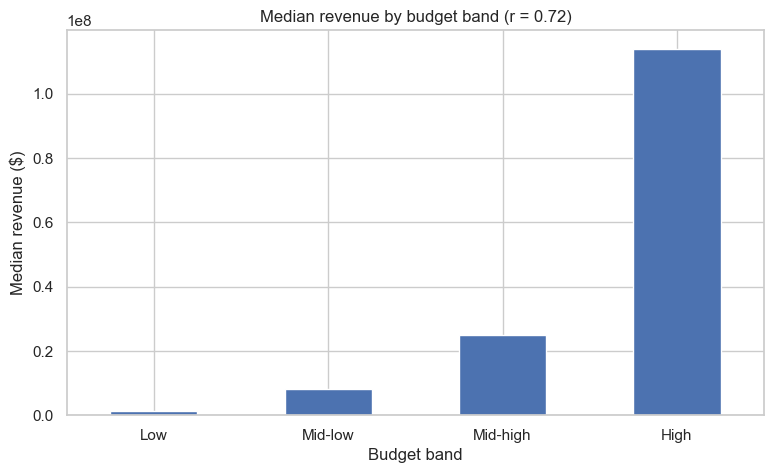

budget_band
Low          1,154,901.00
Mid-low      8,279,017.00
Mid-high    25,001,796.50
High       113,996,937.00
Name: revenue, dtype: float64

In [27]:
# Group films into 4 budget bands, compare median revenue per band
q1 = q1.assign(budget_band=pd.qcut(q1["budget"], 4,
               labels=["Low", "Mid-low", "Mid-high", "High"]))
rev_by_band = q1.groupby("budget_band", observed=True)["revenue"].median()

fig, ax = plt.subplots()
rev_by_band.plot(kind="bar", ax=ax)
ax.set_xlabel("Budget band"); ax.set_ylabel("Median revenue ($)")
ax.set_title(f"Median revenue by budget band (r = {corr:.2f})")
plt.xticks(rotation=0); plt.show()
rev_by_band

**Read:** median revenue rises steadily with each budget band — bigger budgets do bring more
revenue. But check ROI (revenue per $ spent): it does not keep climbing.

In [28]:
q1 = q1.assign(roi=q1["revenue"] / q1["budget"])
q1.groupby("budget_band", observed=True)["roi"].median().rename("median ROI")

budget_band
Low        2.10
Mid-low    1.53
Mid-high   1.40
High       1.96
Name: median ROI, dtype: float64

## Q2. Do Oscar-winning movies receive higher ratings?

Rating = TMDB `vote_average`. Require a minimum vote count so tiny-sample ratings don't distort.

In [29]:
q2 = m[m["vote_count"] >= 50].copy()

summary = q2.groupby("oscar_won")["vote_average"].agg(["mean", "median", "count"])
summary.index = ["Not won", "Oscar winner"]
summary

,mean,median,count
Not won,5.96,6.10,189288
Oscar winner,7.37,7.40,1091


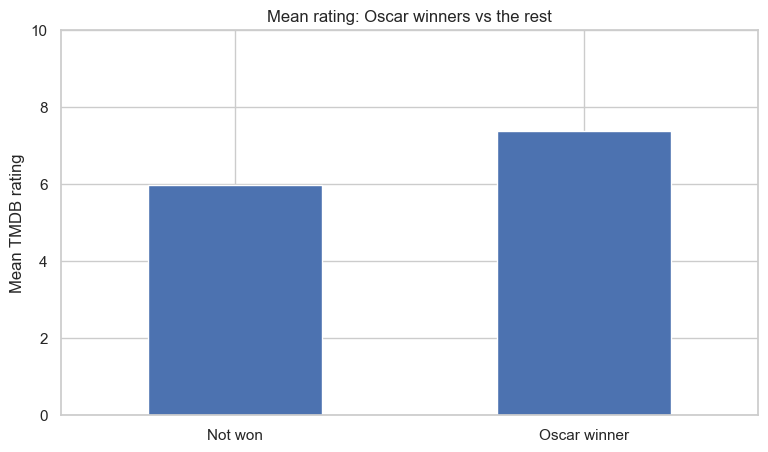

In [30]:
mean_rating = q2.groupby("oscar_won")["vote_average"].mean()
mean_rating.index = ["Not won", "Oscar winner"]

fig, ax = plt.subplots()
mean_rating.plot(kind="bar", ax=ax)
ax.set_ylim(0, 10)
ax.set_xlabel(""); ax.set_ylabel("Mean TMDB rating")
ax.set_title("Mean rating: Oscar winners vs the rest")
plt.xticks(rotation=0); plt.show()

In [31]:
# Welch's t-test (unequal variance) done by hand with numpy — no scipy needed
won = q2.loc[q2["oscar_won"], "vote_average"]
rest = q2.loc[~q2["oscar_won"], "vote_average"]

diff = won.mean() - rest.mean()
se = np.sqrt(won.var(ddof=1) / len(won) + rest.var(ddof=1) / len(rest))
t = diff / se
print(f"winner mean {won.mean():.2f}  vs  rest mean {rest.mean():.2f}")
print(f"difference {diff:.2f}   t = {t:.1f}  (|t| > 2 => significant)")

winner mean 7.37  vs  rest mean 5.96
difference 1.41   t = 73.0  (|t| > 2 => significant)


**Read:** Oscar winners rate clearly higher; the large t-statistic says the gap is not chance.

## Q3. Which genres generate the highest revenue?

TMDB genres are comma-separated (a film can have several), so we split and explode.

In [32]:
q3 = m.dropna(subset=["genres", "revenue"])
q3 = q3[q3["revenue"] > 1000].copy()
# IMDb genres are "Action,Adventure"; TMDB "Action, Adventure" -> split on comma, strip
q3["genre"] = q3["genres"].str.split(",")
q3 = q3.explode("genre")
q3["genre"] = q3["genre"].str.strip()

genre_rev = (q3.groupby("genre")["revenue"]
               .agg(["median", "mean", "count"])
               .sort_values("median", ascending=False))
genre_rev

,median,mean,count
genre,,,
Adventure,"23,000,000.00","130,453,236.28",2528
Action,"16,504,936.00","91,312,459.51",3307
Sci-Fi,"16,000,000.00","119,535,149.10",813
Animation,"14,832,000.00","107,053,776.05",912
Family,"11,137,801.00","65,273,778.59",895
Fantasy,"10,778,972.50","92,353,793.26",1036
Sport,"8,284,000.00","30,376,472.10",317
Science Fiction,"7,948,548.50","7,948,548.50",2
Crime,"7,629,959.00","36,260,705.64",2610


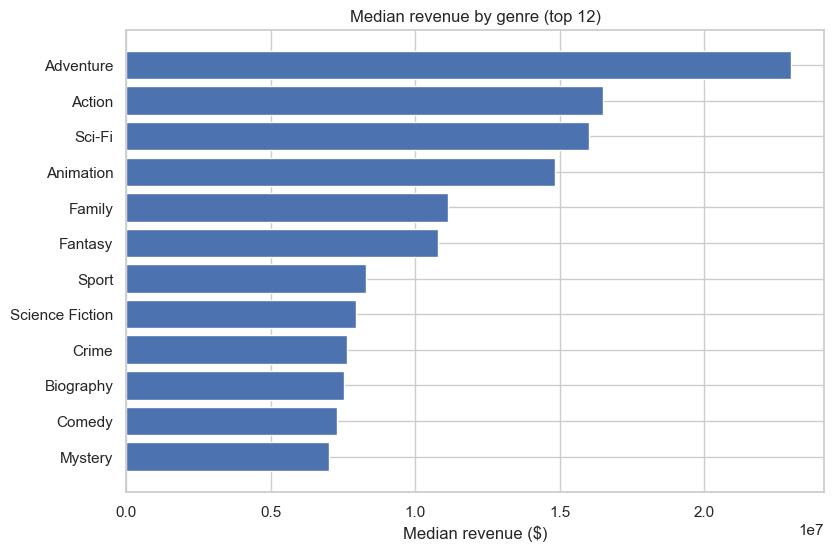

In [33]:
top = genre_rev.head(12)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index[::-1], top["median"][::-1])
ax.set_xlabel("Median revenue ($)")
ax.set_title("Median revenue by genre (top 12)")
plt.show()

**Read:** we rank by **median** (not mean) so a few billion-dollar blockbusters don't inflate a
genre. Adventure / Animation / Fantasy / SciFi lead — the franchise-and-family-friendly end.

## Q4. Does movie runtime influence ratings?

In [34]:
q4 = m[(m["vote_count"] >= 50)].dropna(subset=["runtime", "vote_average"])
q4 = q4[(q4["runtime"] >= 40) & (q4["runtime"] <= 240)]  # plausible feature length

corr_r = q4["runtime"].corr(q4["vote_average"])
print(f"films: {len(q4):,}   corr runtime vs rating: {corr_r:.2f}")

films: 187,198   corr runtime vs rating: 0.16


/var/folders/6h/fxdk7zss6pbb3fd61nq6q__c0000gq/T/ipykernel_59437/4169508058.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_bin = q4.groupby("runtime_bin")["vote_average"].mean()


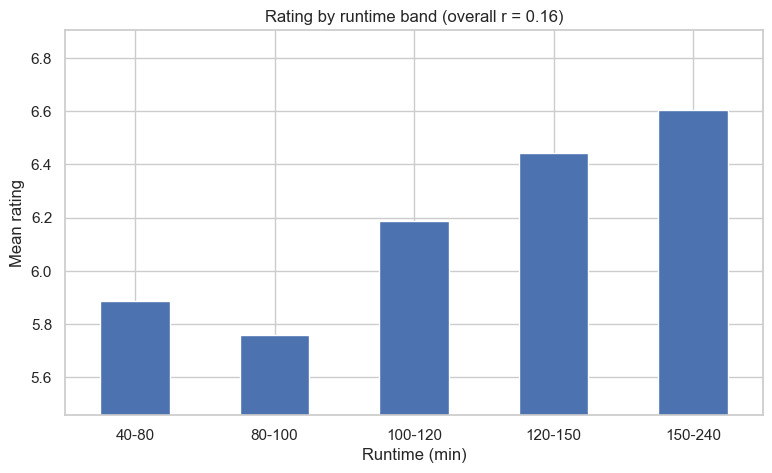

runtime_bin
40-80     5.89
80-100    5.76
100-120   6.19
120-150   6.44
150-240   6.60
Name: vote_average, dtype: float64

In [35]:
q4 = q4.assign(runtime_bin=pd.cut(
    q4["runtime"], bins=[40, 80, 100, 120, 150, 240],
    labels=["40-80", "80-100", "100-120", "120-150", "150-240"]))
by_bin = q4.groupby("runtime_bin")["vote_average"].mean()

fig, ax = plt.subplots()
by_bin.plot(kind="bar", ax=ax)
ax.set_ylim(by_bin.min() - 0.3, by_bin.max() + 0.3)
ax.set_xlabel("Runtime (min)"); ax.set_ylabel("Mean rating")
ax.set_title(f"Rating by runtime band (overall r = {corr_r:.2f})")
plt.xticks(rotation=0); plt.show()
by_bin

**Read:** mild positive link — longer films tend to rate a bit higher, but the effect is small.

## Q5. Which directors consistently produce successful movies?

Directors are in `m` (folded in at Step 5 from the Oscar *Directing* class). Explode co-directed films,
then rank by median revenue. Two counts per director:
- **films_nominated** — directing-nominated films (win or lose)
- **films_won** — of those, ones where they **won** Best Director

"Consistent" = several films **and** a high median. *(Limitation: only Oscar-recognised directing
work appears — not a director's full filmography.)*

In [36]:
# director lives in m now; explode co-directed films ("|")
q5 = m.dropna(subset=["director"]).copy()
q5["director"] = q5["director"].str.split("|")
q5 = q5.explode("director")

# did THIS director WIN Best Director for THIS film? (director_won holds the winners)
q5["won_as_director"] = [
    isinstance(dw, str) and d in dw.split("|")
    for d, dw in zip(q5["director"], q5["director_won"])
]
q5["won_imdb"] = q5["imdb_id"].where(q5["won_as_director"])   # imdb_id only when won
print("director-film rows:", len(q5), "| directing wins:", int(q5["won_as_director"].sum()))
q5[["director", "title", "revenue", "vote_average", "won_as_director"]].head()

director-film rows: 503 | directing wins: 103


,director,title,revenue,vote_average,won_as_director
10951,Frank Borzage,7th Heaven,NaN,7.50,True
10993,Herbert Brenon,Sorrell and Son,NaN,5.80,False
11069,Lewis Milestone,Two Arabian Knights,NaN,6.60,True
11328,King Vidor,The Crowd,NaN,8.00,False
11702,Ernst Lubitsch,The Patriot,NaN,5.00,False


In [37]:
director_stats = (q5.dropna(subset=["revenue"])
    .groupby("director")
    .agg(films_nominated=("imdb_id", "nunique"),   # directing-nominated films
         films_won=("won_imdb", "nunique"),        # of those, directing WINS
         median_revenue=("revenue", "median"),
         median_rating=("vote_average", "median"))
    .query("films_nominated >= 3")
    .sort_values("median_revenue", ascending=False))
director_stats.head(15)

,films_nominated,films_won,median_revenue,median_rating
director,,,,
Quentin Tarantino,3,0,"321,457,747.00",8.40
Steven Spielberg,9,2,"306,889,114.00",7.60
David O. Russell,3,0,"236,412,453.00",7.70
David Fincher,3,0,"224,920,315.00",7.80
Peter Weir,4,0,"223,935,613.50",7.80
Ang Lee,3,2,"213,525,736.00",7.90
Martin Scorsese,9,1,"185,770,160.00",7.80
Ridley Scott,3,0,"172,989,651.00",7.70
Oliver Stone,3,2,"161,001,698.00",8.00


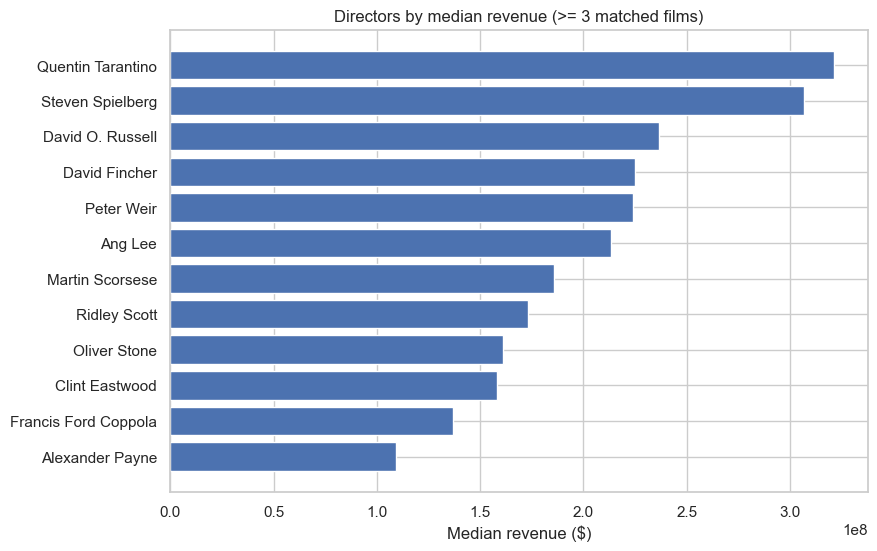

In [38]:
top_d = director_stats.head(12)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_d.index[::-1], top_d["median_revenue"][::-1])
ax.set_xlabel("Median revenue ($)")
ax.set_title("Directors by median revenue (>= 3 matched films)")
plt.show()

## Conclusions

1. **Budget → revenue:** positive correlation, but wide spread — money helps, doesn't guarantee. Median ROI actually falls in the top budget quartile.
2. **Oscars → ratings:** winners rate significantly higher than non-winners.
3. **Genre revenue:** Adventure / Animation / Fantasy / SciFi top median revenue; Documentary lowest.
4. **Runtime → rating:** weak positive link; longer films rate slightly better.
5. **Directors:** among Oscar-recognised directors, a handful pair high median revenue with 3+ films (see table).

**Caveats:** TMDB reports many budget/revenue as 0 (dropped as missing); director analysis limited to Oscar Directing nominees; ratings are TMDB votes, not IMDb.